In [1]:
"""Collect the Hubbard Brook meteorological data and save to a csv file 
   good for creating forcing NetCDF from.

   Instead of downscaling temperature and wind speed from ERA, 
   disaggregate the daily data using other observed diurnal range to gapfill.
"""
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress
import numpy as np
import itertools as it
from sklearn.model_selection import KFold
from tqdm import tqdm
from multiprocessing import Pool
from typing import Tuple, Union

## 1. Read observations

In [2]:
""" Solar radiation: W m-2
    2014-2019 only
    15 min interval resample to 1 hour"""
path_root = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook')

solrad = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.237.1', 'HBEF_15minSolarRadiation_WX1.csv'))

start_date = pd.Timestamp(year = 2014, month = 7, day = 21, hour = 10, minute = 30)
end_date = pd.Timestamp(year = 2019, month = 4, day = 3, hour = 10, minute = 30)
date_range = pd.date_range(start_date, end_date, freq='15T')

solrad.index = date_range

# average over two stations
solrad = (solrad['SolRad1'] + solrad['SolRad2']) / 2
solrad = solrad.resample('1H').mean()

""" Long term daily precipitation """
precip = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.14.18', 'dailyWatershedPrecip1956-2023.csv'), index_col = 0, parse_dates = True)
precip = precip.query('watershed == "W1"')['Precip']


""" 15 minute rain gauge, 2011/8/26-2023
Some values are gap-filled from other stations, which is okay
Summed to mm/hour
"""
precip = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.277.8', 
                                  'HBEF_RG1precipitation_15min.csv'),
                     index_col = 1, parse_dates=True)
precip = precip['precip'].resample('1H').sum()

""" 15 minute air temperature, 2015-2023
"""
tair = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.322.4', 
                                'HBEF_STA1airTemp_15min.csv'), 
                   index_col = 1, parse_dates=True)
tair = tair['airTemp'].resample('1H').mean()

""" Long term daily air temperature """
tair_daily = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'Hubbard_Brook',
                                      'knb-lter-hbr.59.14', 'HBEF_air_temp_daily_1957-2024.csv'), 
                                      index_col = [1,0], parse_dates = True
                        ).loc['STA1', ['MAX','MIN']]
tair_daily = tair_daily.dropna(axis = 0, how = 'any')
tair_daily = tair_daily.loc[tair_daily.index.year >= 2011, :]

""" 15 minute relative humidity, 2011-2023 (%)
"""
rh = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.336.2', 
                              'HBEF_STA1_RH_15min.csv'),
                 index_col = 0, parse_dates=True)
rh = rh['STA1_RH'].resample('1H').mean()

""" 15 minutes wind speed, 2014-2023 (m/s)
"""
wind = pd.read_csv(os.path.join(path_root, 'knb-lter-hbr.337.3', 'HBEF_STA1_wind_15min.csv'),
                 index_col = 0, parse_dates=True)
wind = wind['WS_ms_Avg'].resample('1H').mean()

""" Long term daily wind speed """
wind_daily = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 
                                      'Hubbard_Brook', 'knb-lter-hbr.56.12',
                                      'HBEF_wind_daily_1981-2025.csv'),
                         index_col = 0, parse_dates=True)
wind_daily = wind_daily.loc[wind_daily.index.year >= 2011, 'WS_ms_Avg']

/tmp/ipykernel_2410096/1749536632.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range = pd.date_range(start_date, end_date, freq='15T')
/tmp/ipykernel_2410096/1749536632.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  solrad = solrad.resample('1H').mean()
/tmp/ipykernel_2410096/1749536632.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  precip = precip['precip'].resample('1H').sum()
/tmp/ipykernel_2410096/1749536632.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tair = tair['airTemp'].resample('1H').mean()
/tmp/ipykernel_2410096/1749536632.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tair_daily = pd.

## 2. Read ERA5 and find the time lag

In [3]:
def read_era5(variable):
    filelist = [os.path.join(os.environ['PROJDIR'], "ERW_LDRD", "data", "GEE", "HubbardBrook", 
                             f"HubbardBrook_{variable}_{year}.csv") \
                for year in range(2011, 2024)]
    alldata = []
    for file in filelist:
        alldata = alldata + [pd.read_csv(file, index_col = 0, parse_dates=True)[variable]]
    alldata = pd.concat(alldata)
    if variable == "temperature_2m":
        alldata = alldata - 273.15
    if "radiation" in variable:
        alldata = alldata / 3600
    return alldata

tair_era = read_era5("temperature_2m")
solrad_era = read_era5("surface_solar_radiation_downwards_hourly")
wind_era = np.sqrt(read_era5("u_component_of_wind_10m")**2 + \
                   read_era5("v_component_of_wind_10m")**2)
ifrrad_era = read_era5("surface_thermal_radiation_downwards_hourly")
pres_era = read_era5("surface_pressure")

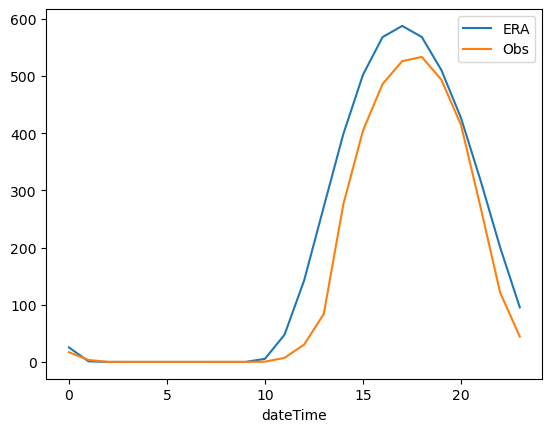

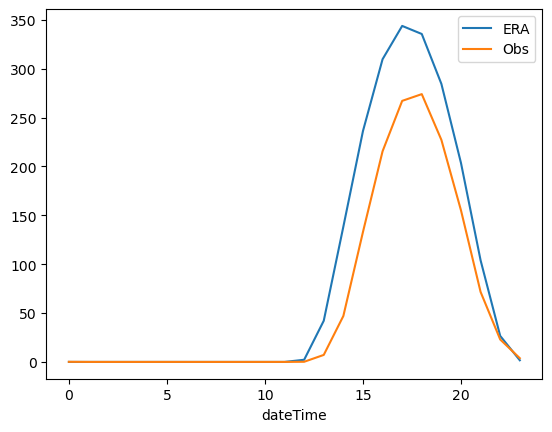

In [4]:
# Check the number of hours shifted
def daylight_savings(tvec):
    dm = tvec.month * 100 + tvec.day
    return (dm >= 310) & (dm <= 1103)

tshift = 6

summer_era = solrad_era.loc[daylight_savings(solrad_era.index)]
summar_obs = solrad.loc[daylight_savings(solrad.index)]

winter_era = solrad_era.loc[~daylight_savings(solrad_era.index)]
winter_obs = solrad.loc[~daylight_savings(solrad.index)]

plt.figure()
summer_era.groupby(summer_era.index.hour).mean().plot(label="ERA")
summar_obs_cycle = summar_obs.groupby(summar_obs.index.hour).mean()
summar_obs_cycle.index = np.mod(summar_obs_cycle.index + tshift, 24)
summar_obs_cycle.sort_index().plot(label = "Obs")
plt.legend()

plt.figure()
winter_era.groupby(winter_era.index.hour).mean().plot(label="ERA")
winter_obs_cycle = winter_obs.groupby(winter_obs.index.hour).mean()
winter_obs_cycle.index = np.mod(winter_obs_cycle.index + tshift, 24)
winter_obs_cycle.sort_index().plot(label="Obs")
plt.legend()

In [5]:
# shift the hour of the observation to UTC
def shift_data(df, hours):
    df = df.copy()
    df.index = df.index + pd.Timedelta(hours = hours)
    return df

solrad_shifted = shift_data(solrad, tshift)
tair_shifted = shift_data(tair, tshift)
rh_shifted = shift_data(rh, tshift)
wind_shifted = shift_data(wind, tshift).dropna()
precip_shifted = shift_data(precip, tshift)

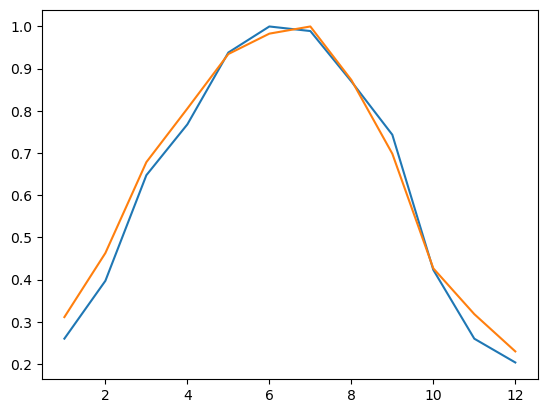

In [6]:
# Check the seasonal cycle between ERA5 and observed solar radiation
obs_sea = (solrad_shifted.groupby(solrad_shifted.index.month).mean() / solrad_shifted.groupby(solrad_shifted.index.month).mean().max())

era_sea = (solrad_era.groupby(solrad_era.index.month).mean() / solrad_era.groupby(solrad_era.index.month).mean().max())

plt.plot(obs_sea, label = 'Obs')
plt.plot(era_sea, label = 'ERA5')
#plt.plot(obs_sea / era_sea.values)

## 3. Disaggreate the air temperature and wind speed

precip & rh are already 2011-2023, does not need gap-filling

thermal radiation & air pressure can only use ERA5-Land data

continue to use ERA5-Land solar rad, because the observed solar 
   rad may be shaded

divide the daily air temperature and wind speed by the average
   diurnal cycle of the same day of the year in the gaps

In [7]:
# Prepare the metdata array
metdata_all = pd.concat([precip_shifted, rh_shifted, ifrrad_era, pres_era, 
                         solrad_era],
                        axis = 1, join = 'inner')
metdata_all.columns = ['Precip (mm/hour)', 'RH (%)', 'RLDS (W/m2)', 'Pressure (Pa)', 
                       'RSDS']

# Check to make sure no missing days after join
tdiff = (metdata_all.index[-1] - metdata_all.index[0])
print(tdiff.total_seconds() / 3600)

101602.0


In [8]:
# -----------------------------------------------------------------------------
# Helper utilities
# -----------------------------------------------------------------------------

def _nearest_doy(target: int, available: np.ndarray) -> int:
    """Return the nearest day-of-year (1-365) in *available* (wrap-around)."""
    if target in available:
        return target
    diff = np.abs(available - target)
    circ = np.minimum(diff, 365 - diff)
    return int(available[circ.argmin()])


def _harmonise_indices(hourly: pd.Series, daily_index: pd.DatetimeIndex) -> Tuple[pd.Series, pd.DatetimeIndex, np.ndarray, np.ndarray]:
    """Reindex *hourly* so that it covers *daily_index* entirely and return helpers."""
    full_range = pd.date_range(
        daily_index.min(),
        daily_index.max() + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
        freq="h",
        tz=hourly.index.tz,
    )
    hourly = hourly.reindex(full_range)
    hour_of_day = hourly.index.hour
    doy = hourly.index.dayofyear
    dates = hourly.index.normalize()
    return hourly, dates, hour_of_day, doy

# -----------------------------------------------------------------------------
# 1. Max/min-based infilling (unchanged apart from helper extraction)
# -----------------------------------------------------------------------------

def fill_from_diurnal(
    hourly: pd.Series,
    daily: pd.DataFrame,
    min_complete_hours: int = 20,
    fallback_to_nearest: bool = True,
) -> pd.Series:
    """Fill gaps using daily **MAX/MIN** and a climatological diurnal cycle.

    Parameters
    ----------
    hourly : pd.Series
        Hourly observations (may contain NaNs) with a `DateTimeIndex`.
    daily : pd.DataFrame
        DataFrame indexed by date (00:00) with columns **"MAX"** and **"MIN"**.
    min_complete_hours : int, default 20
        A day is considered usable for the climatology if it has at least this
        many non-missing hourly readings.
    fallback_to_nearest : bool, default True
        If the exact day-of-year template is missing, fall back to the template
        from the nearest DOY (circular distance).
    """

    # ------------------------------------------------------------------
    # Harmonise indices -------------------------------------------------
    # ------------------------------------------------------------------
    daily = daily.copy()
    daily.index = pd.to_datetime(daily.index).normalize()
    hourly, dates, hour_of_day, doy = _harmonise_indices(hourly, daily.index)

    # ------------------------------------------------------------------
    # Build DOY climatology (fraction of daily range) -------------------
    # ------------------------------------------------------------------
    valid_day = hourly.groupby(dates).apply(lambda s: s.notna().sum() >= min_complete_hours)
    good_days = valid_day[valid_day].index

    records = []
    for d in good_days:
        day_slice = hourly[d.strftime("%Y-%m-%d")]
        dmin, dmax = day_slice.min(), day_slice.max()
        if pd.isna(dmin) or pd.isna(dmax) or dmax == dmin:
            continue
        records.append(
            ((day_slice - dmin) / (dmax - dmin)).to_frame("frac").assign(
                hour=day_slice.index.hour,
                doy=d.dayofyear,
            )
        )

    if not records:
        raise RuntimeError("No sufficiently complete days to derive a diurnal template.")

    norm_df = pd.concat(records)
    doy_hour_template = norm_df.groupby(["doy", "hour"])["frac"].mean().unstack("hour")
    available_doys = doy_hour_template.index.values

    # ------------------------------------------------------------------
    # Fill gaps ---------------------------------------------------------
    # ------------------------------------------------------------------
    filled = hourly.copy()

    for this_doy, this_day in zip(doy, dates):
        day_mask = dates == this_day
        if filled[day_mask].isna().any():
            if this_doy in doy_hour_template.index:
                frac = doy_hour_template.loc[this_doy]
            elif fallback_to_nearest:
                frac = doy_hour_template.loc[_nearest_doy(this_doy, available_doys)]
            else:
                continue  # leave NaNs

            dmax = daily.at[this_day, "MAX"]
            dmin = daily.at[this_day, "MIN"]
            amp = dmax - dmin

            for h in range(24):
                pos = day_mask & (hour_of_day == h)
                if filled[pos].isna().any():
                    filled.loc[pos] = dmin + frac[h] * amp

    return filled

# -----------------------------------------------------------------------------
# 2. Mean-based infilling -----------------------------------------------------
# -----------------------------------------------------------------------------

def fill_from_diurnal_mean(
    hourly: pd.Series,
    daily_mean: pd.Series,
    min_complete_hours: int = 20,
    fallback_to_nearest: bool = True,
) -> pd.Series:
    """Fill gaps using a daily **average** and a climatological diurnal shape.

    The infilling algorithm:

    1.  Identify “good” days (≥ ``min_complete_hours`` valid hourly points).
    2.  For every good day, compute *shape factors* = hourly value ÷ daily mean.
        By construction, the factors for a day average to 1.0.
    3.  For each calendar day-of-year, average these factors across all good
        years to obtain a 24-hour template whose mean is again 1.0.
    4.  If a target DOY lacks a template, optionally substitute the template of
        the nearest DOY in circular distance (1 ↔ 365).
    5.  When filling a missing hour on day *D* with daily mean *m*:

        ``value = factor[h] * m``

        Existing (non-missing) observations are preserved.

    Parameters
    ----------
    hourly : pd.Series
        Hourly observations with a `DateTimeIndex` (may include NaNs).
    daily_mean : pd.DataFrame
        Daily *average* values.
    min_complete_hours : int, default 20
        Minimum number of valid hourly points in a day for it to be considered
        when building the climatology.
    fallback_to_nearest : bool, default True
        Use the nearest-DOY template if the exact template is missing.
    column : str | None
        Name of the column to extract if *daily_mean* is a DataFrame.
    """

    # ------------------------------------------------------------------
    # Normalise daily_mean input ---------------------------------------
    # ------------------------------------------------------------------
    daily = daily_mean.to_frame(name="MEAN")
    daily.index = pd.to_datetime(daily.index).normalize()

    # ------------------------------------------------------------------
    # Harmonise indices -------------------------------------------------
    # ------------------------------------------------------------------
    hourly, dates, hour_of_day, doy = _harmonise_indices(hourly, daily.index)

    # ------------------------------------------------------------------
    # Build DOY climatology (shape factors relative to daily mean) ------
    # ------------------------------------------------------------------
    valid_day = hourly.groupby(dates).apply(lambda s: s.notna().sum() >= min_complete_hours)
    good_days = valid_day[valid_day].index

    records = []
    for d in good_days:
        day_slice = hourly[d.strftime("%Y-%m-%d")]
        day_mean = day_slice.mean()
        if pd.isna(day_mean) or day_mean == 0:
            continue
        records.append(
            (day_slice / day_mean).to_frame("shape").assign(
                hour=day_slice.index.hour,
                doy=d.dayofyear,
            )
        )

    if not records:
        raise RuntimeError("No sufficiently complete days to derive a diurnal template.")

    shape_df = pd.concat(records)
    doy_hour_shape = shape_df.groupby(["doy", "hour"])["shape"].mean().unstack("hour")
    available_doys = doy_hour_shape.index.values

    # ------------------------------------------------------------------
    # Fill gaps ---------------------------------------------------------
    # ------------------------------------------------------------------
    filled = hourly.copy()

    for this_doy, this_day in zip(doy, dates):
        day_mask = dates == this_day
        if filled[day_mask].isna().any():
            if this_doy in doy_hour_shape.index:
                factors = doy_hour_shape.loc[this_doy]
            elif fallback_to_nearest:
                factors = doy_hour_shape.loc[_nearest_doy(this_doy, available_doys)]
            else:
                continue  # leave NaNs if no template

            dmean = daily.at[this_day, "MEAN"]
            for h in range(24):
                pos = day_mask & (hour_of_day == h)
                if filled[pos].isna().any():
                    filled.loc[pos] = factors[h] * dmean

    return filled

In [9]:
tair_filled = fill_from_diurnal(tair, tair_daily)
wind_filled = fill_from_diurnal_mean(wind, wind_daily)

In [10]:
metdata_all['Tair'] = tair_filled
metdata_all['Wind'] = wind_filled

metdata_all.to_csv('./temp/downscaling_result.csv')

[None, None, None, None, None, None, None, None]

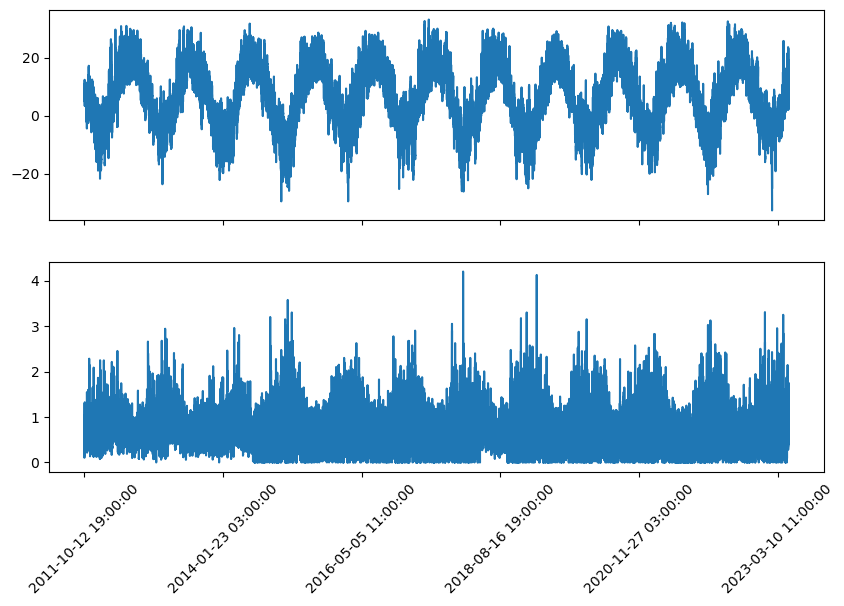

In [11]:
# Check the gap-filled diurnal cycle and daily statistics
metdata_all = pd.read_csv('./temp/downscaling_result.csv', index_col=0)
fig, axes = plt.subplots(2, 1, figsize = (10, 6), sharex = True)
metdata_all['Tair'].plot(ax = axes.flat[0])
#metdata_all['RSDS'].plot(ax = axes.flat[1])
metdata_all['Wind'].plot(ax = axes.flat[1])
plt.setp(axes.flat[0].get_xticklabels(), rotation=45)
plt.setp(axes.flat[1].get_xticklabels(), rotation=45)

/tmp/ipykernel_2410096/4168297018.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (t[0] > 0):


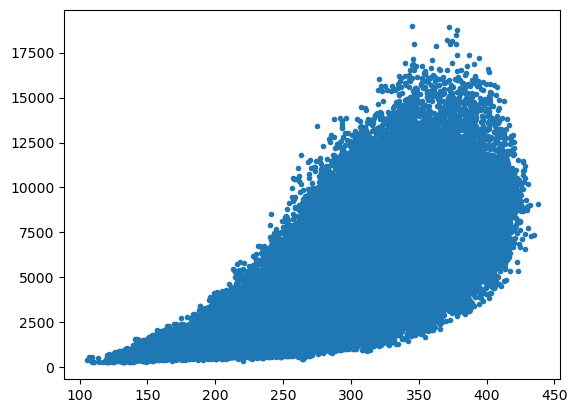

In [12]:
# Check the ERA longwave radiation against what is calculated from T and RH
# The ERA ones clearly make much more sense

def esat(t):
    #coefficients for calculating saturation vapor pressure
    a = [6.107799961, 4.436518521e-01, 1.428945805e-02, 2.650648471e-04, \
            3.031240396e-06, 2.034080948e-08, 6.136820929e-11]
    b = [6.109177956, 5.034698970e-01, 1.886013408e-02, 4.176223716e-04, \
            5.824720280e-06, 4.838803174e-08, 1.838826904e-10]
    if (t[0] > 0):
        myesat = (a[0]+t*(a[1]+t*(a[2]+t*(a[3]+t*(a[4]+t*(a[5]+t*a[6]))))))
    else:
        myesat = (b[0]+t*(b[1]+t*(b[2]+t*(b[3]+t*(b[4]+t*(b[5]+t*b[6]))))))
    myesat = myesat * 100. # convert from hPa to Pa
    return myesat


stebol = 5.67e-8
mye = esat(metdata_all['Tair']) * metdata_all['RH (%)'] / 100
ea = 0.70 + 5.95e-5*mye*np.exp(1500.0/(metdata_all['Tair'] + 273.15))
flds = ea * stebol * (metdata_all['Tair'] + 273.15) ** 4

plt.plot(metdata_all['RLDS (W/m2)'], flds, '.')

## 4. Use the nearest neighbor to fill in small holes in RH

In [13]:
metdata_all = pd.read_csv(os.path.join("temp", "downscaling_result.csv"), 
                          index_col = 0, parse_dates=True)

In [14]:
def find_nearest_neighbor(df, date_index):
    """ Find the nearest neighbor wthin +/- 7 days for a given date index with 
    a missing RH value. """

    # Filter for within ±7 days
    target_date = date_index.date()
    start_date = target_date - pd.Timedelta(days=7)
    end_date = target_date + pd.Timedelta(days=7)
    date_filter = (df.index.date >= start_date) & (df.index.date <= end_date)

    # Filter for similar met conditions
    met_filter = (np.abs(df['RSDS'] - df.at[date_index, 'RSDS']) <= 50) & \
                 (np.abs(df['Tair'] - df.at[date_index, 'Tair']) <= 2.5) # & \
                 # (np.abs(df['VPD'] - df.at[date_index, 'VPD']) <= 500)

    subset_df = df[date_filter & met_filter]

    # Drop the row with the missing value itself and any additional missing values
    subset_df = subset_df.drop(index=date_index).dropna()

    if len(subset_df) == 0:
        print(date_index)
        return np.nan

    # Calculate distances based on 'RLDS (W/m2)' and 'Tair'
    distances = subset_df.apply(lambda row: np.sqrt( \
        ((row['RSDS'] - df.at[date_index, 'RSDS']) / df['RSDS'].std()) **2 +
        ((row['Tair'] - df.at[date_index, 'Tair']) / df['Tair'].std()) **2), axis=1)

    # Find the index of the minimum distance
    nearest_neighbor_index = distances.idxmin()

    return subset_df.at[nearest_neighbor_index, 'RH (%)']

# Fill in the missing values
val_set = []
for index, row in metdata_all.loc[metdata_all['RH (%)'].isna(), :].iterrows():
    val_set.append(find_nearest_neighbor(metdata_all, index))
metdata_all.loc[metdata_all['RH (%)'].isna(), 'RH (%)'] = np.array(val_set)

2021-08-09 18:00:00
2021-08-09 19:00:00
2021-08-12 12:00:00
2021-08-15 18:00:00
2021-08-15 19:00:00
2022-07-01 12:00:00
2022-07-02 13:00:00


In [15]:
metdata_all.loc[pd.date_range('2021-08-15 10:00:00', '2021-08-15 23:00:00', freq = '1H'), :]

/tmp/ipykernel_2410096/3487687954.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  metdata_all.loc[pd.date_range('2021-08-15 10:00:00', '2021-08-15 23:00:00', freq = '1H'), :]


,Precip (mm/hour),RH (%),RLDS (W/m2),Pressure (Pa),RSDS,Tair,Wind
2021-08-15 10:00:00,0.0,100.00,294.149722,95748.648438,0.159444,19.125,0.961869
2021-08-15 11:00:00,0.0,90.75,292.774444,95798.187500,65.977222,19.750,1.093328
2021-08-15 12:00:00,0.0,100.00,293.076667,95821.667969,235.070556,19.500,1.148237
2021-08-15 13:00:00,0.0,78.75,295.575833,95807.992188,425.005556,20.000,1.152013
2021-08-15 14:00:00,0.0,65.25,300.052778,95839.093750,600.995556,18.750,1.076977
2021-08-15 15:00:00,0.0,61.50,309.208889,95859.402344,731.888333,17.750,1.109441
2021-08-15 16:00:00,0.0,51.00,315.906111,95859.210938,809.664444,16.875,1.158695
2021-08-15 17:00:00,0.0,47.50,309.994722,95845.679688,863.631667,15.500,1.079570
2021-08-15 18:00:00,0.0,NaN,309.820278,95772.539062,881.802222,13.750,1.220128
2021-08-15 19:00:00,0.0,NaN,313.059167,95788.363281,819.334444,13.125,0.400000


In [16]:
# fill by constants since the above results shows steady changes
metdata_all.loc[metdata_all['RH (%)'].isna(), 'RH (%)'] = 72

In [17]:
metdata_all.to_csv(f'./temp/downscaling_result_final.csv')

In [18]:
metdata_all.shape, metdata_all.dropna(axis = 0, how='any').shape

((101603, 7), (101603, 7))